In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout ,Input, GlobalAveragePooling2D
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam
from keras import layers
from keras.applications import ResNet50

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

2026-03-01 19:41:29.501193: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 19:41:29.672196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# directory where images are located
data_dir = "../data/original"
image_size = (32, 32)
batch_size = 128

file_paths = []
labels = []

# the name of each folder corresponds to the label of the images within
class_names = os.listdir(data_dir)
class_to_index = {name: i for i, name in enumerate(class_names)}

# for each folder, we'll save the path of each file with its correspondent label
for class_name in class_names:
    class_dir = f"{data_dir}/{class_name}"
    images = sorted(os.listdir(class_dir))
    for img_path in images:
        file_paths.append(class_dir + "/" + str(img_path))
        labels.append(class_to_index[class_name])

# now we have all the paths and labels together
file_paths = np.array(file_paths)

# bad_files = []

# for path in file_paths:
#     try:
#         if not check_jpeg(path):
#             bad_files.append(path)
#     except:
#         bad_files.append(path)

# print("invalid files:" +  str(len(bad_files)))

# todo: include if

# fix bad_files (already done)
# for path in bad_files:
#     img = Image.open(path)
#     new_path = path.rsplit(".", 1)[0] + ".jpg"
#     img.convert("RGB").save(new_path, "JPEG")

In [3]:
labels = np.array(labels)
dimension = 3

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

X_train_full, y_train_full = load_full_dataset(X_train, y_train)
X_train_full = X_train_full.numpy().astype(int).squeeze()
y_train_labels = np.argmax(y_train_full.numpy(), axis = 1)

X_test_full, y_test_full = load_full_dataset(X_test, y_test)
X_test_full = X_test_full.numpy().astype(int).squeeze()
y_test_labels = np.argmax(y_test_full.numpy(), axis = 1)


I0000 00:00:1772390496.844427    1305 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-01 19:41:39.268752: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-01 19:41:40.021902: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
class_weights = dict(enumerate(class_weights))

## Baseline

In [5]:
def build_baseline_model(n_filters = 64, n_neurons = 64, learning_rate = 1e-2, momentum = 0.0, 
                      kernel_size = 3, pool_size = 2, sparse = True, **kwargs):
    '''Builds the first CNN architecture. This model is intended to be very simple, to start understanding how well it performs over the dataset
        and to start developing more complex models. It uses basic concepts of CNNs: a convolution layer followed by a pooling layer, then a dense layer with a final
        softmax given output.
        
    Args:
        - n_filters (int): number of filters to be used on convolution layers (Conv2D). Default set to 64.
        - n_neurons (int): number of neurons to be used on dense layers (Dense). Default set to 64.
        - learning_rate (float): indicates a which rate the gradient moves. Default set to 1e-2.
        - momentum (float): proportion regarding how much of past gradients affect the current gradient step. Default set to 0.0.
        - kernel_size (int): indicates the size of the squared sliding window over the feature map. Default set to 3.
        - pool_size (int): indicated the size of the downsample pooling window. Default set to 2.
        - sparse (bool): sets if labels should be considered as one-hot (False) or integers (True). Default set to True.
        - other parameters such as activation function (ReLU), padding (same) and activation (softmax) were kept as default throught all architectures.
    Returns:
        - model: fully compiled model with all respective features.
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [6]:
which_arch = "baseline"

param_grid = {"learning_rate": [1e-2, 1e-3],
              "momentum": [0.0, 0.9],
              "kernel_size": [2,3],
              "n_filters": [16, 32, 64],
              "n_neurons": [16, 32, 64]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, mean_scores, result_df = CNN_GridSearchCV(X_train_full, y_train_labels, param_grid, build_baseline_model, 42, 5, n_jobs = 1, batch_size=batch_size)

result_df.to_csv(root_logdir(which_arch)+"/CV/cv_result.csv")

combination 0
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 16, 'n_neurons': 16}


2026-03-01 18:18:58.118799: I external/local_xla/xla/service/service.cc:163] XLA service 0x79f838006ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-01 18:18:58.118825: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-01 18:18:58.131656: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-01 18:18:58.164487: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
I0000 00:00:1772385540.119098  298215 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


combination 1
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 16, 'n_neurons': 32}
combination 2
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 16, 'n_neurons': 64}
combination 3
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 16}
combination 4
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 32}
combination 5
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 64}


2026-03-01 18:20:45.669845: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:20:45.669891: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:20:45.669900: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:20:46.274661: I external/l

combination 6
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 16}
combination 7
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 32}


2026-03-01 18:21:34.320941: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:34.320981: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:34.320990: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:34.946284: I external/l

combination 8
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 64}


2026-03-01 18:21:58.881846: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:58.881887: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:58.881898: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 18:21:59.515115: I external/l

combination 9
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 16, 'n_neurons': 16}
combination 10
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 16, 'n_neurons': 32}
combination 11
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 16, 'n_neurons': 64}
combination 12
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 32, 'n_neurons': 16}
combination 13
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 32, 'n_neurons': 32}
combination 14
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 32, 'n_neurons': 64}
combination 15
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 64, 'n_neurons': 16}
combination 16
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 64, 'n_neurons': 32}
combination 17
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_s

In [10]:
result_df.sort_values("val_accuracy", ascending = False)

,learning_rate,momentum,kernel_size,n_filters,n_neurons,val_loss,val_accuracy
32,0.010,0.9,3,32,64,2.131952,0.244429
35,0.010,0.9,3,64,64,2.133198,0.236938
31,0.010,0.9,3,32,32,2.132885,0.236094
30,0.010,0.9,3,32,16,2.164189,0.225510
29,0.010,0.9,3,16,64,2.161843,0.222516
...,...,...,...,...,...,...,...
43,0.001,0.0,2,64,32,2.295316,0.111729
63,0.001,0.9,3,16,16,2.296201,0.106201
64,0.001,0.9,3,16,32,2.294188,0.105636
60,0.001,0.9,2,64,16,2.294489,0.104046


In [12]:
best_accuracy

np.float64(0.2444288194179535)

In [7]:
best_params

{'learning_rate': 0.01,
 'momentum': 0.9,
 'kernel_size': 3,
 'n_filters': 32,
 'n_neurons': 64}

In [11]:
mean_scores

[(np.float64(2.310389280319214), np.float64(0.115845987200737)),
 (np.float64(2.303067207336426), np.float64(0.12118262648582459)),
 (np.float64(2.2930901527404783), np.float64(0.11490921974182129)),
 (np.float64(2.280951738357544), np.float64(0.12193182110786438)),
 (np.float64(2.2991357803344727), np.float64(0.11490921974182129)),
 (np.float64(2.2939707756042482), np.float64(0.11631375700235366)),
 (np.float64(2.2854867935180665), np.float64(0.11781184077262878)),
 (np.float64(2.291016960144043), np.float64(0.11490921974182129)),
 (np.float64(2.290017032623291), np.float64(0.11490921974182129)),
 (np.float64(2.2908370971679686), np.float64(0.11996781229972839)),
 (np.float64(2.2998092651367186), np.float64(0.11490921974182129)),
 (np.float64(2.2960120677947997), np.float64(0.12867642045021058)),
 (np.float64(2.3026520729064943), np.float64(0.12146348059177399)),
 (np.float64(2.2941120624542237), np.float64(0.11490921974182129)),
 (np.float64(2.3021896362304686), np.float64(0.11725004

In [13]:
run_id, run_logdir = get_run_logdir(which_arch, "1")

# different callbacks to: save the best model over validation set, save logs of loss and accuracy for later visualization and early stopping.
tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

# compile the model
model = build_baseline_model(**best_params)

# train
# we use a higher number of epochs since early stopping should stop since it reaches a no-improvement point.
model.fit(X_train_full, y_train_labels, epochs=50, class_weight=class_weights, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

# with the best parameters achieved, we train the first model and evaluate for the test error
save_params(run_logdir, "best_params_baseline_model.pkl",best_params)

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1132 - loss: 2.2583
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1686 - loss: 2.1486
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2139 - loss: 2.0991
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2315 - loss: 2.0634
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2716 - loss: 2.0107
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2973 - loss: 1.9401
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3087 - loss: 1.8761
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3209 - loss: 1.8381
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3323 - loss: 1.8155
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.3417 - loss: 1.7935
Epoch 11/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3456 - loss: 1.7701
Epoch 12/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 1

## Custom model

In [5]:
def build_custom_model(n_filters = 128, n_neurons = 64, learning_rate = 1e-2, dropout_rate = 0.5, 
                      kernel_size = 3, pool_size = 2, beta_2 = 0.99, sparse = True, momentum = 0.9 ,**kwargs):
    '''
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Conv2D(int(n_filters*2), kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dropout(dropout_rate),
    Dense(int(n_neurons/2), activation="relu"),
    Dropout(dropout_rate),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [6]:
which_arch = "custom"

param_grid = {"learning_rate": [1e-2, 1e-3],
              "kernel_size" : [3, 5],
              "beta_2": [0.99, 0.999],
              "n_filters": [64, 128],
              "n_neurons": [64, 128]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, mean_scores, result_df  = CNN_GridSearchCV(X_train_full, y_train_labels, param_grid, build_custom_model, 42, 5,n_jobs=1 ,batch_size=batch_size)

result_df.to_csv(root_logdir(which_arch)+"/CV/cv_result.csv")

combination 0
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 64}


2026-03-01 19:41:45.383192: I external/local_xla/xla/service/service.cc:163] XLA service 0x762610002210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-01 19:41:45.383219: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-01 19:41:45.435003: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-01 19:41:45.614598: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-01 19:41:45.749802: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:41:45.

combination 1
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 128}


2026-03-01 19:42:48.506300: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:42:48.506347: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:42:48.506370: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:42:48.506385: I external/l

combination 2
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 64}


2026-03-01 19:43:55.080605: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:43:55.080658: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:43:55.522889: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1189', 124 bytes spill stores, 124 bytes spill loads

2026-03-01 19:43:55.724343: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

combination 3
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 128}


2026-03-01 19:45:14.968634: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:45:14.968683: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 19:45:15.131750: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1189', 4 bytes spill stores, 4 bytes spill loads

2026-03-01 19:45:15.655282: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

combination 4
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 64, 'n_neurons': 64}
combination 5
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 64, 'n_neurons': 128}
combination 6
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 128, 'n_neurons': 64}
combination 7
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 128, 'n_neurons': 128}
combination 8
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 64}
combination 9
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 128}
combination 10
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 64}
combination 11
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 128}
combination 12
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2':

In [8]:
best_params

{'learning_rate': 0.001,
 'kernel_size': 5,
 'beta_2': 0.999,
 'n_filters': 128,
 'n_neurons': 128}

In [9]:
best_accuracy

np.float64(0.4425951838493347)

In [10]:
run_id, run_logdir = get_run_logdir(which_arch, "2")

tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

model = build_custom_model(**best_params)    
# here we can save the best model
model.fit(X_train_full, y_train_labels, epochs=50, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

save_params(run_logdir, "best_params_custom_model.pkl", best_params)
# best_params = {'learning_rate': 0.01, 'momentum': 0.9, 'n_filters': 32, 'n_neurons': 64}

Epoch 1/50


2026-03-01 20:29:17.678573: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:17.678617: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:17.678649: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:17.678659: I external/l

332/334 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1417 - loss: 2.2704

2026-03-01 20:29:25.346990: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:25.347035: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:25.347064: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:29:25.649662: I external/l

334/334 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.1532 - loss: 2.2463
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1917 - loss: 2.1554
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2705 - loss: 2.0288
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3414 - loss: 1.8557
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3812 - loss: 1.7724
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4082 - loss: 1.6974
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4293 - loss: 1.6393
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4532 - loss: 1.5967
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4631 - loss: 1.5564
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4856 - loss: 1.5132
Epoch 11/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4993 - loss: 1.4694
Epoch 12/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accura

In [11]:
run_logdir

'./logs/custom/2_run_2026_03_01-17_26_17'

In [11]:
model.evaluate(X_test_full, y_test_labels)

2026-03-01 20:31:47.682047: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-01 20:31:48.026904: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 100 bytes spill stores, 100 bytes spill loads



84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6562 - loss: 1.5502


[1.5502300262451172, 0.6561797857284546]

In [28]:
model.evaluate(X_test_full, y_test_labels)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6592 - loss: 2.0123


[2.012279748916626, 0.6591760516166687]

In [23]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)

84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [25]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names)

              precision    recall  f1-score   support

     clothes       0.82      0.83      0.82       397
  biological       0.78      0.58      0.67       162
       trash       0.43      0.44      0.44        99
       paper       0.50      0.64      0.56       276
       glass       0.69      0.71      0.70       400
     battery       0.67      0.64      0.65       163
       shoes       0.70      0.70      0.70       327
       metal       0.35      0.41      0.38       198
     plastic       0.60      0.59      0.60       342
   cardboard       0.81      0.61      0.70       306

    accuracy                           0.65      2670
   macro avg       0.64      0.62      0.62      2670
weighted avg       0.66      0.65      0.65      2670



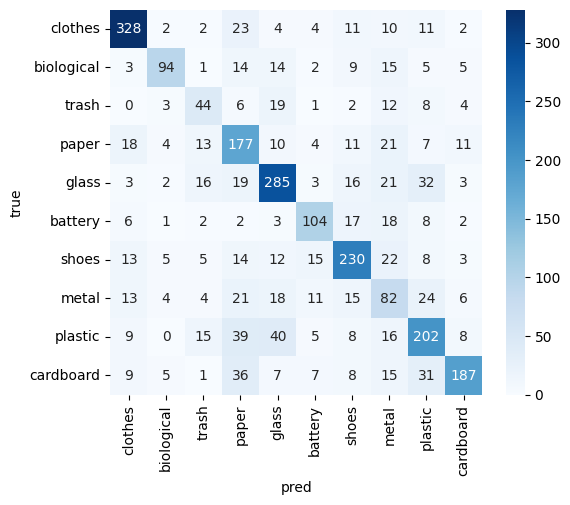

In [26]:
plot_conf_matrix(cm)

In [ ]:
cm = compute_classification_metrics(y_test_array, y_pred, class_names)

              precision    recall  f1-score   support

     clothes       0.91      0.42      0.57       397
  biological       0.43      0.80      0.55       162
       trash       0.41      0.41      0.41        99
       paper       0.58      0.44      0.50       276
       glass       0.69      0.49      0.58       400
     battery       0.80      0.29      0.42       163
       shoes       0.61      0.52      0.56       327
       metal       0.26      0.49      0.34       198
     plastic       0.44      0.69      0.54       342
   cardboard       0.62      0.69      0.65       306

    accuracy                           0.53      2670
   macro avg       0.57      0.52      0.51      2670
weighted avg       0.61      0.53      0.54      2670



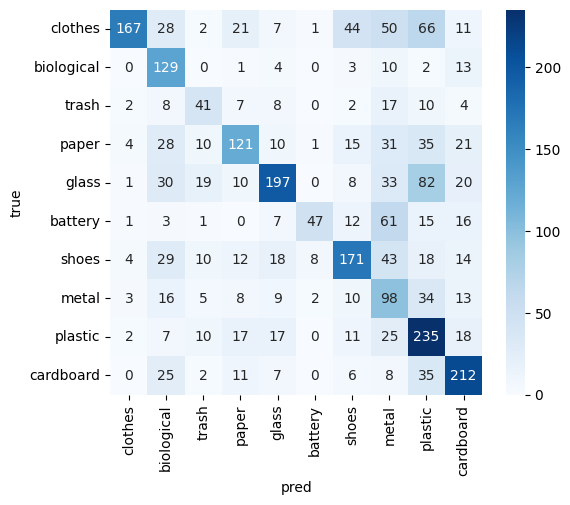

In [ ]:
plot_conf_matrix(cm)